### Outliers with z-score + visualization

In [35]:
import numpy as np
import pandas as pd
from scipy import stats
df = pd.read_csv("../houses.csv")
# load dataset
variable = "price"
z_scores = stats.zscore(df[variable])

# Define a threshold for outliers
# modify this as needed, default is 3 (based on normal distribution)
# try this with 2 or 2.5, and then see how much data we lose 
# even if the distribution is closer to normal distribution now
threshold = 5.5

# Detect outliers
outliers = df[np.abs(z_scores) > threshold]

print("Detected outliers using Z-score:")
outliers

Detected outliers using Z-score:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
269,7960900060,20150504T000000,2900000.0,4,3.25,5050,20100,1.5,0,2,...,11,4750,300,1982,2008,98004,47.6312,-122.223,3890,20060
300,3225069065,20140624T000000,3075000.0,4,5.00,4550,18641,1.0,1,4,...,10,2600,1950,2002,0,98074,47.6053,-122.077,4550,19508
656,3760500116,20141120T000000,3070000.0,3,2.50,3930,55867,1.0,1,4,...,8,2330,1600,1957,0,98034,47.7022,-122.224,2730,26324
1164,1247600105,20141020T000000,5110800.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
1315,7558700030,20150413T000000,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20460,9808100150,20150402T000000,3345000.0,5,3.75,5350,15360,1.0,0,1,...,11,3040,2310,2008,0,98004,47.6480,-122.218,3740,15940
20535,1370800515,20141030T000000,2950000.0,4,4.25,4470,5884,2.0,0,1,...,11,3230,1240,2010,0,98199,47.6387,-122.405,2570,6000
21040,6447300365,20141113T000000,2900000.0,5,4.00,5190,14600,2.0,0,1,...,11,5190,0,2013,0,98039,47.6102,-122.225,3840,19250
21530,8964800330,20150407T000000,3000000.0,4,3.75,5090,14823,1.0,0,0,...,11,4180,910,2013,0,98004,47.6200,-122.207,3030,12752


**This version of the visualization shows the dataset from 1st to last house in original order.**

We can see how scattered the outlier houses are based on price this way.

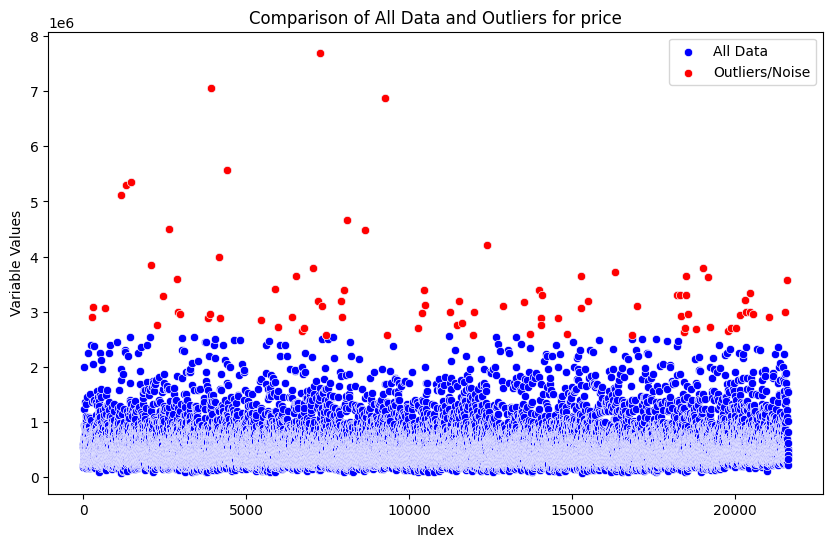

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot setup
plt.figure(figsize=(10, 6))

# which variable we are visualizing, usually a variable 
# we detected the outliers from or target variable
variable = "price"

# NOTE! outliers is the dataframe that contains only the outliers or noise items

# Plot the full dataset (in blue, for example)
sns.scatterplot(x=df.index, y=df[variable], color='blue', label='All Data')

# Overlay the outliers (in red)
sns.scatterplot(x=outliers.index, y=outliers[variable], color='red', label='Outliers/Noise')

# Add title and labels
plt.title(f'Comparison of All Data and Outliers for {variable}')
plt.xlabel('Index')
plt.ylabel('Variable Values')

# Show legend
plt.legend()

# Display the plot
plt.show()

<Axes: >

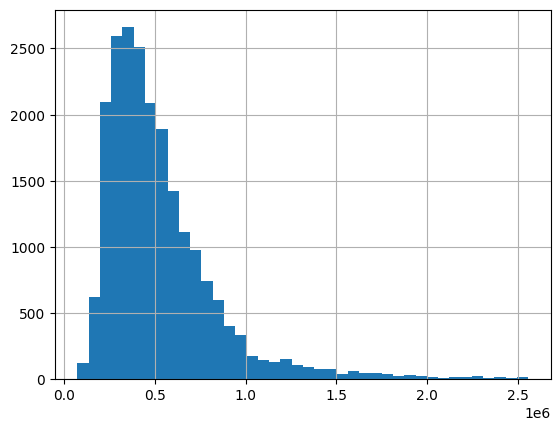

In [37]:
# take the original dataframe MINUS the outliers
inliers = df[~df.index.isin(outliers.index)]


inliers['price'].hist(bins=40)